In [1]:
from pathlib import Path
import sys
root = Path.cwd()
if root.name == "notebooks":
    root = root.parent
sys.path.insert(0, str(root))

from src.data_download import download_data
import json 
import pandas as pd
import pickle
import os

data_dir = Path("../data")

In [2]:
# List the categories to download here
categories = ["All_Beauty"]
reload_data = False

if reload_data:
    for category in categories:
        download_data(category)


## Overview of the dataset

We performed the following EDA to inspect the datasets:
- **Dataset size inspection:** Counted the number of records in both datasets (reviews and metadata).
- **Field inspection:** Listed all available fields in the reviews and metadata datasets.
- **Sample record inspection:** Printed example records from both datasets to understand the data structure and relationships between fields.
- **Missing value analysis:** Calculated the percentage of missing values for each field to determine data completeness.
- **Rating distribution analysis:** Visualized the distribution of review ratings to understand overall sentiment patterns in the dataset.

In [3]:
for category in categories:
    review_file = f"../data/raw/{category}.jsonl"
    metadata_file = f"../data/raw/meta_{category}.jsonl"

    print(f"Data exploration for {category} dataset:")

    # Read reviews
    reviews = []
    with open(review_file, "r") as f:
        for line in f:
            reviews.append(json.loads(line))

    # Read metadata
    meta = []
    with open(metadata_file, "r") as f:
        for line in f:
            meta.append(json.loads(line))

    print("Reviews count:", len(reviews))
    print("Metadata count:", len(meta))

    print("Review fields:", list(reviews[0].keys()))
    print("Metadata fields:", list(meta[0].keys()))

    print("First review:", reviews[0])
    print("First metadata record:", meta[0])


Data exploration for All_Beauty dataset:
Reviews count: 701528
Metadata count: 112590
Review fields: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']
Metadata fields: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together']
First review: {'rating': 5.0, 'title': 'Such a lovely scent but not overpowering.', 'text': "This spray is really nice. It smells really good, goes on really fine, and does the trick. I will say it feels like you need a lot of it though to get the texture I want. I have a lot of hair, medium thickness. I am comparing to other brands with yucky chemicals so I'm gonna stick with this. Try it!", 'images': [], 'asin': 'B00YQ6X8EO', 'parent_asin': 'B00YQ6X8EO', 'user_id': 'AGKHLEW2SOWHNMFQIJGBECAF7INQ', 'timestamp': 1588687728923, 'helpful_vote': 0, 'verified_purchase': Tr

In [4]:
reviews_df = pd.DataFrame(reviews)
meta_df = pd.DataFrame(meta)

In [5]:
print("Percentage of missing values in reviews:")
print(reviews_df.isna().mean() * 100)
print("Percentage of missing values in metadata:")
print(meta_df.isna().mean() * 100) 

Percentage of missing values in reviews:
rating               0.0
title                0.0
text                 0.0
images               0.0
asin                 0.0
parent_asin          0.0
user_id              0.0
timestamp            0.0
helpful_vote         0.0
verified_purchase    0.0
dtype: float64
Percentage of missing values in metadata:
main_category        0.000000
title                0.000000
average_rating       0.000000
rating_number        0.000000
features             0.000000
description          0.000000
price               84.275691
images               0.000000
videos               0.000000
store               10.063949
categories           0.000000
details              0.000000
parent_asin          0.000000
bought_together    100.000000
dtype: float64


Rating distribution:


<Axes: >

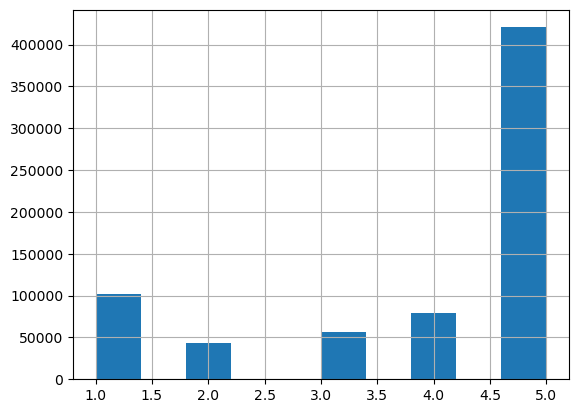

In [6]:
print("Rating distribution:")
reviews_df["rating"].hist()

## Selection and justification of fields for retrieval

We selected the following subset of fields for retrieval from the reviews and metadaset as these fields contain meaningful textual information describing the product and how the other users felt after using the product.

| Dataset   | Field | Reason for Inclusion |
|----------|-------|----------------------|
| Metadata | title | Contains product title which identifies the product type, brand and keywords related to the product that are often directly represented in the user's product query. |
| Reviews  | text  | Contains product reviews from other users of how relevant and useful the product is in natural language. |

## Description of text preprocessing decisions

We performed the following text preprocessing in the text_tokenizer function in the bm25.py script:
- **Lowercasing**  
   All text was converted to lowercase to ensure that all tokens are treated as the same word. This reduces unnecessary vocabulary duplication and improves matching between queries and documents.

- **Punctuation Removal**  
   Punctuation characters were removed using a regular expression. This ensures that all tokens are treated consistently and prevents punctuation from being included as part of tokens.

- **Whitespace Tokenization**  
   After normalization, text was split into tokens using whitespace.

- **Stopword Removal**  
   Common English stopwords (e.g., *the*, *and*, *is*, *to*) were removed to reduce noise in the tokenized corpus. These words appear frequently but provide little semantic value for distinguishing relevant documents.

In [7]:
from langchain_core.documents import Document
from src.bm25 import text_tokenizer, build_bm25, bm25_search

tokenized_corpus_file = os.path.join(data_dir, "processed", "tokenized_corpus.pkl")
reload_tokenized_corpus = True

documents = []
tokenized_corpus = []

metadata_lookup = {
    item["parent_asin"]: item
    for item in meta
}

if os.path.exists(tokenized_corpus_file) and not reload_tokenized_corpus:
    print("Loading tokenized corpus...")
    
    with open(tokenized_corpus_file, "rb") as f:
        tokenized_corpus = pickle.load(f)

else:
    print("Generating tokenized corpus...")

for review in reviews:

    product_metadata = metadata_lookup.get(review["parent_asin"], {})

    combined_text = " ".join([
        product_metadata.get("title", ""),              # used in old version
        # " ".join(product_metadata.get("description", [])),
        # " ".join(product_metadata.get("features", [])),
        # review.get("title", ""),
        review.get("text", "")
    ])

    tokens = text_tokenizer(combined_text)

    tokenized_corpus.append(tokens)


with open(tokenized_corpus_file, "wb") as f:
    pickle.dump(tokenized_corpus, f)


# Build documents (needed for BM25 search)
for tokens, review in zip(tokenized_corpus, reviews):

    processed_text = " ".join(tokens)

    product_metadata = metadata_lookup.get(review["parent_asin"], {})

    documents.append(
        Document(
            page_content=processed_text,
            metadata={
                "asin": review["parent_asin"],
                "product_review": review.get("text", ""),
                "product_title": product_metadata.get("title", ""),
                "product_rating": review.get("rating", "")
            }
        )
    )


Generating tokenized corpus...


In [8]:
bm25_index_path = "../data/processed/bm25_index.pkl"
rebuild_bm25 = True

if os.path.exists(bm25_index_path) and not rebuild_bm25:

    print("Loading existing BM25 index...")

    with open(bm25_index_path, "rb") as f:
        bm25 = pickle.load(f)

else:

    print("Building BM25 index...")

    bm25 = build_bm25(documents)

    with open(bm25_index_path, "wb") as f:
        pickle.dump(bm25, f)

Building BM25 index...


In [9]:
from src.utils import deduplicate_results, format_result, results_to_html

queries = [
    # Easy (Keyword-based)
    "ultra facial barrier-hydrating cleanser",
    "AM Facial Moisturizing Lotion SPF 30",
    "fit me concealer",
    "cheek heat gel cream blush, face makeup",
    # Medium (Semantic-based)
    "something to keep your face moisturized all day",
    "makeup to cover up pimples",
    "comfortable lotion for rigid weather",
    # Complex
    "best sunscreen for scuba diving in tropical regions",
    "what’s the best hair treatment to prevent hair loss",
    "good cleanser for busy working professionals who do not have time"
]

In [11]:
from src.semantic import semantic_search

all_results = {}

for query in queries:
    bm25_results = bm25_search(bm25, documents, query, k=5)
    semantic_results = semantic_search(
        documents,
        query,
        k=5,
        sample_size=10000,
        reload_index=False
    )

    all_results[query] = {
        "bm25": bm25_results,
        "semantic": semantic_results
    }

In [12]:
formatted_results = {}

for query, result_dict in all_results.items():
    bm25_formatted = [format_result(r) for r in result_dict["bm25"]]
    semantic_formatted = [format_result(r) for r in result_dict["semantic"]]

    formatted_results[query] = {
        "bm25": bm25_formatted,
        "semantic": semantic_formatted,
    }

In [13]:
import pandas as pd
from IPython.display import display, HTML

rows = []

for query, result_dict in formatted_results.items():
    rows.append({
        "Query": query,
        "BM25 Results": results_to_html(result_dict["bm25"]),
        "Semantic Results": results_to_html(result_dict["semantic"])
    })

df = pd.DataFrame(rows)
display(HTML(df.to_html(escape=False, index=False)))

Query,BM25 Results,Semantic Results
ultra facial barrier-hydrating cleanser,"1. Neutrogena Ultra Light Facial Cleansing Oil & Makeup Remover, Non-Comedogenic Face Oil Cle...ASIN: B00U2VQZC4 | Score: 17.7932. Savannah Bee Company Propolis Extract Volcanic Ash and Charcoal Facial CleanserASIN: B077V7KZC2 | Score: 14.6113. Facial Cleansing Brush with Ultra Hygienic Soft Silicone,PLAVOGUE 3 in 1 Waterproof Sonic ...ASIN: B09747TST8 | Score: 14.1084. COSMETEA Facial Tea Stick Balm Cleanser - Black tea + Omija - Moisture CareASIN: B075WZFK66 | Score: 14.0475. Facial Cleansing Brush made with Ultra Hygienic Soft Silicone 4-PACKASIN: B08GR16Y3Z | Score: 13.965","1. GOMAY Hydrating Amino Acid Foaming Facial Cleanser, Daily Face Wash for Makeup Remover wit...ASIN: B09ZDQ626L | Score: 0.6302. REBONCEL Aqua Rich Hydrating Face Foam Cleanser Gentle Hypoallergenic pH Balance Korean Sk...ASIN: B09X23VTSQ | Score: 0.6643. Hylunia Hydrate Body Wash - Energizing Blend With Mango 8.5 ozASIN: B07YNDWRCB | Score: 0.7084. Black Wolf - Men’s Gentle Hydrating Face Wash - 5 Fl Oz - Hydrating Sugar Technology Blend...ASIN: B08GMW3HNG | Score: 0.7165. CELIMAX The Real Sedum Aqua Boosting Essence - with 65.33% Sedum Extract, Hyaluronic Acid ...ASIN: B084WP4XS8 | Score: 0.732"
AM Facial Moisturizing Lotion SPF 30,"1. CeraVe AM Facial Moisturizing Lotion SPF 30 | Oil-Free Face Moisturizer with Sunscreen | N...ASIN: B010PJYJIY | Score: 31.7622. C'est Moi Tinted Moisturizing Lotion SPF 30 | Gentle, Hydrating Formula Provides Broad Spe...ASIN: B087QVX3JL | Score: 25.3023. L'Oreal Paris Age Perfect Hydra-Nutrition Facial Day Lotion SPF 30 (Pack of 2)ASIN: B073VX7KTY | Score: 24.8374. OROGOLD SPF 30 Gold Moisturizer – Day Cream with SPF 30 For Sun Protection - Moisturizing ...ASIN: B07WSQBQMF | Score: 23.2105. Trader Joe's Enrich Moisturizing Face Lotion SPF 15, Trader Joe's Aloe Vera Gel, Trader Jo...ASIN: B071HB6H37 | Score: 22.155","1. Fresh Black Tea Age-Delay Lotion Broad Spectrum Sunscreen SPF 20, 1.6 OunceASIN: B00MAYT8GQ | Score: 0.5322. Alpha Hydrox Sheer Silk Moisturizer SPF 15, 1 OunceASIN: B000N9IQLS | Score: 0.6133. Anew Reversalist Complete Renewal Day Lotion SPF 25ASIN: B00JND88A4 | Score: 0.6214. Lesentia Tinted Moisturizer with SPF 31 – Tinted Moisturizer For Face With Spf and Blemish...ASIN: B0855L611L | Score: 0.6535. Clinique Dramatically Different Moisturizing Lotion Combination Dry To Dry Skin 4.2 Ounce ...ASIN: B00HSH0DPU | Score: 0.714"
fit me concealer,1. L.a Girl Pro Concealer Hd High-definition Concealer ( Pack of 3 ) Gc973ASIN: B00HEU0EZK | Score: 15.1542. Maybelline New York Fit Me Concealer 6.8ml - 25 MediumASIN: B007B8UOPK | Score: 15.0693. LA Girl HD Conceal High Definition Pro Concealer 11 Color Choices (Fawn)ASIN: B017WPO3B2 | Score: 12.4004. ETUDE Big Cover Skin Fit Concealer PRO (# Neutral Peach) (21AD) | Long-Lasting Closely Adh...ASIN: B08CVGMFRB | Score: 11.5505. Sonia Kashuk Hidden Agenda II Concealer Palette Medium 08ASIN: B072WGHV9K | Score: 10.913,"1. Boo-Boo Cover-Up Healing Concealer, Medium, 0.13 OunceASIN: B07FX823ZQ | Score: 0.7282. US-LONG-DREAM Professional 15 Color Concealer Camouflage Makeup Palette With a BrushASIN: B00VFU35EW | Score: 0.8723. Ucanbe 15 Color Concealer Palette Cream Contour Kit With Pro Foundation Concealer Face Con...ASIN: B01F8P1TI8 | Score: 0.9094. Tarte Shape Tape Contour Concealer | DeepASIN: B07JHHJXMG | Score: 0.9275. LA Girl HD Conceal High Definition Pro Concealer 11 Color Choices (Fawn)ASIN: B017WPO3B2 | Score: 0.946"
"cheek heat gel cream blush, face makeup","1. All Natural Cream Blush for Lip & Cheek Makeup Contouring, Swept AwayASIN: B07Y2CKDDM | Score: 25.3322. [3 Pack] LSxia Liquid Blush Makeup Gifts for Women, Natural Looking Breathable Feel Cream ...ASIN: B09MB5GCXF | Score: 25.1993. [6 Pack] LSxia Liquid Blush Makeup Gifts for Women, Natural Looking Breathable Feel Cream ...ASIN: B0924RRTM9 | Score: 24.9254. [3 Pack] LSxia Liquid Blush for Cheeks, Natural Looking Breathable 

In [14]:
selected_queries = [
    # Easy (Keyword-based)
    "ultra facial barrier-hydrating cleanser",
    # Medium (Semantic-based)
    "something to keep your face moisturized all day",
    "makeup to cover up pimples",
    # Complex
    "best sunscreen for scuba diving in tropical regions",
    "good cleanser for busy working professionals who do not have time"
]

In [ ]:
selected_results = {}

for query in selected_queries:
    bm25_results = bm25_search(bm25, documents, query, k=5)
    semantic_results = semantic_search(
        documents,
        query,
        k=5,
        sample_size=10000,
        reload_index=False
    )

    selected_results[query] = {
        "bm25": bm25_results,
        "semantic": semantic_results
    }

In [ ]:
selected_formatted_results = {}

for query, result_dict in selected_results.items():
    bm25_formatted = [format_result(r) for r in result_dict["bm25"]]
    semantic_formatted = [format_result(r) for r in result_dict["semantic"]]
    selected_formatted_results[query] = {
        "bm25": bm25_formatted,
        "semantic": semantic_formatted,
    }

rows = []

for query, result_dict in selected_formatted_results.items():
    rows.append({
        "Query": query,
        "BM25 Results": results_to_html(result_dict["bm25"]),
        "Semantic Results": results_to_html(result_dict["semantic"])
    })

df = pd.DataFrame(rows)
display(HTML(df.to_html(escape=False, index=False)))